# Chapter 6: Ensemble Methods

**AFML Ch. 6** -- Bagging accuracy and ensemble effects, plus HRP (Ch. 16) as a practical ensemble allocation method.

This notebook demonstrates:

- Theoretical bagging accuracy curve (how ensemble size amplifies edge)
- Hierarchical Risk Parity (HRP) portfolio weights
- Inverse Variance Portfolio (IVP) weights
- Allocation comparison: HRP vs CLA vs IVP via Monte Carlo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance

%matplotlib inline

np.random.seed(42)

## Theoretical Bagging Accuracy

Given an individual classifier with accuracy `p`, the ensemble accuracy of `N` independent
classifiers (majority vote) is given by the binomial CDF. Key insight:

- For `p > 0.5`, ensemble accuracy converges to 1.0 as N increases
- For `p < 0.5`, ensemble accuracy converges to 0.0 (worse than individual!)
- For `p = 0.5`, ensemble accuracy stays at 0.5 regardless of N

In [2]:
print("Individual accuracy -> Ensemble accuracy (N classifiers)")
for p in [0.45, 0.50, 0.51, 0.55, 0.60, 0.70]:
    accs = []
    for n in [3, 11, 51, 101, 501]:
        acc = pymlfinance.modeling.bagging_accuracy(n, p)
        accs.append(f"N={n}: {acc:.4f}")
    print(f"  p={p:.2f} -> {', '.join(accs)}")

Individual accuracy -> Ensemble accuracy (N classifiers)
  p=0.45 -> N=3: 0.4253, N=11: 0.3669, N=51: 0.2359, N=101: 0.1562, N=501: 0.0124
  p=0.50 -> N=3: 0.5000, N=11: 0.5000, N=51: 0.5000, N=101: 0.5000, N=501: 0.5000
  p=0.51 -> N=3: 0.5150, N=11: 0.5271, N=51: 0.5571, N=101: 0.5799, N=501: 0.6729
  p=0.55 -> N=3: 0.5748, N=11: 0.6331, N=51: 0.7641, N=101: 0.8438, N=501: 0.9876
  p=0.60 -> N=3: 0.6480, N=11: 0.7535, N=51: 0.9265, N=101: 0.9791, N=501: 1.0000
  p=0.70 -> N=3: 0.7840, N=11: 0.9218, N=51: 0.9986, N=101: 1.0000, N=501: 1.0000


### Ensemble Accuracy Curve

Plotting the ensemble accuracy as a function of the number of classifiers for different
individual accuracy levels.

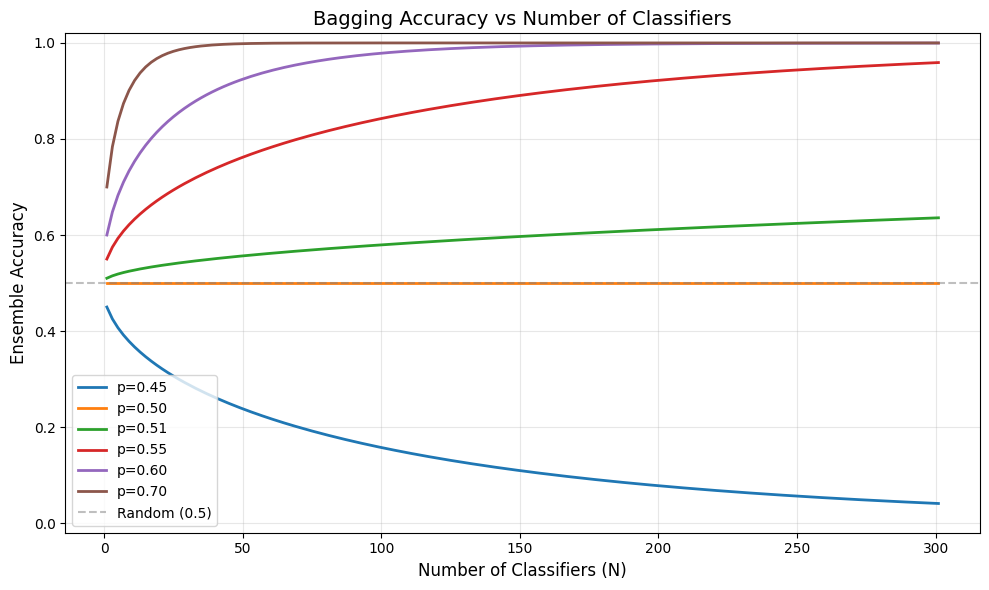

In [3]:
n_values = list(range(1, 302, 2))  # odd numbers only for majority vote
p_values = [0.45, 0.50, 0.51, 0.55, 0.60, 0.70]

fig, ax = plt.subplots(figsize=(10, 6))

for p in p_values:
    ensemble_accs = [pymlfinance.modeling.bagging_accuracy(n, p) for n in n_values]
    ax.plot(n_values, ensemble_accs, label=f"p={p:.2f}", linewidth=2)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set_xlabel('Number of Classifiers (N)', fontsize=12)
ax.set_ylabel('Ensemble Accuracy', fontsize=12)
ax.set_title('Bagging Accuracy vs Number of Classifiers', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hierarchical Risk Parity (HRP)

HRP is a tree-based portfolio allocation method that does not require covariance matrix
inversion. It uses hierarchical clustering to group correlated assets, then allocates
risk top-down through the dendrogram.

In [4]:
n_assets = 5
n_periods = 252
# Simulate correlated asset returns
factors = np.random.randn(n_periods, 2)
betas = np.random.randn(2, n_assets) * 0.3
returns = factors @ betas + np.random.randn(n_periods, n_assets) * 0.01

hrp_w = pymlfinance.features.hrp_weights(returns)
print(f"{n_assets} assets, {n_periods} periods")
print(f"HRP weights: [{', '.join(f'{w:.4f}' for w in hrp_w)}]")
print(f"Sum: {np.sum(hrp_w):.4f}")

5 assets, 252 periods
HRP weights: [0.1202, 0.4321, 0.2577, 0.0926, 0.0973]
Sum: 1.0000


## Inverse Variance Portfolio (IVP)

IVP allocates weights inversely proportional to each asset's variance. It is a simple
baseline that ignores correlations entirely.

In [5]:
cov = pymlfinance.core.covariance_matrix(returns)
ivp_w = pymlfinance.features.inverse_variance_weights(cov)
print(f"IVP weights: [{', '.join(f'{w:.4f}' for w in ivp_w)}]")
print(f"Sum: {np.sum(ivp_w):.4f}")

IVP weights: [0.0959, 0.3446, 0.2948, 0.1291, 0.1356]
Sum: 1.0000


### HRP vs IVP Weight Comparison

Comparing the two allocation methods side by side. HRP accounts for correlation structure
while IVP only considers individual variances.

In [6]:
print(f"{'Asset':<8} {'HRP':>8} {'IVP':>8} {'Diff':>8}")
for i in range(n_assets):
    diff = hrp_w[i] - ivp_w[i]
    print(f"{f'Asset {i}':<8} {hrp_w[i]:>8.4f} {ivp_w[i]:>8.4f} {diff:>+8.4f}")

Asset         HRP      IVP     Diff
Asset 0    0.1202   0.0959  +0.0244
Asset 1    0.4321   0.3446  +0.0876
Asset 2    0.2577   0.2948  -0.0370
Asset 3    0.0926   0.1291  -0.0365
Asset 4    0.0973   0.1356  -0.0384


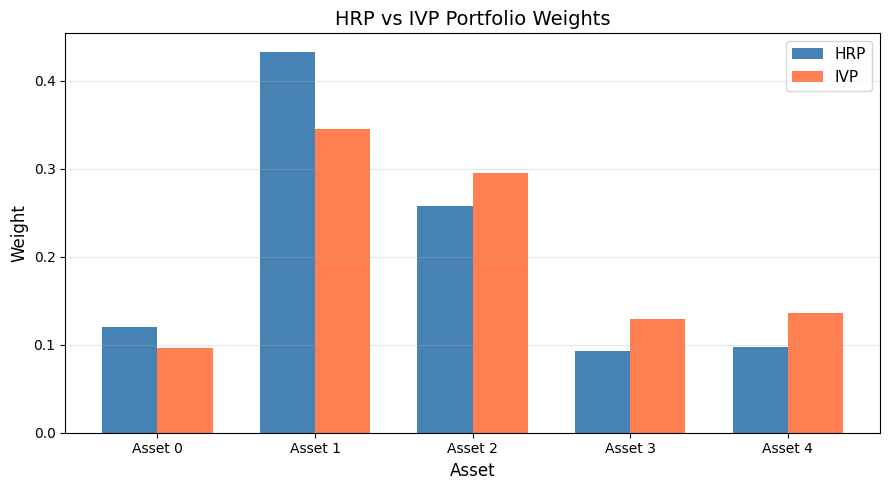

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(n_assets)
width = 0.35

bars1 = ax.bar(x - width/2, hrp_w, width, label='HRP', color='steelblue')
bars2 = ax.bar(x + width/2, ivp_w, width, label='IVP', color='coral')

ax.set_xlabel('Asset', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.set_title('HRP vs IVP Portfolio Weights', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'Asset {i}' for i in range(n_assets)])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Monte Carlo Allocation Comparison

Running a Monte Carlo simulation to compare HRP, CLA, and IVP across multiple
random draws. This gives a more robust comparison of expected Sharpe ratio and variance.

In [8]:
comparison = pymlfinance.features.compare_allocations(returns, n_simulations=50, seed=42)
print(f"HRP  -- Sharpe: {comparison.hrp_sharpe:.4f}, Variance: {comparison.hrp_variance:.6f}")
print(f"CLA  -- Sharpe: {comparison.cla_sharpe:.4f}, Variance: {comparison.cla_variance:.6f}")
print(f"IVP  -- Sharpe: {comparison.ivp_sharpe:.4f}, Variance: {comparison.ivp_variance:.6f}")

HRP  -- Sharpe: -0.0717, Variance: 0.026264
CLA  -- Sharpe: -0.0356, Variance: 0.000282
IVP  -- Sharpe: -0.0703, Variance: 0.030653


## Exercises

1. Increase the number of assets and observe how HRP scales vs IVP
2. Vary individual classifier accuracy `p` from 0.45 to 0.60 and plot the ensemble curve
3. Add a highly correlated asset pair and compare how HRP and IVP handle it